In [1]:
import tensorflow as tf

/opt/anaconda3/envs/tf311/lib/python3.11/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
from tensorflow.keras import models,layers

In [3]:
import matplotlib.pyplot as plt

In [4]:
IMAGE_SIZE=256
BATCH_SIZE=32

In [5]:
dataset=tf.keras.preprocessing.image_dataset_from_directory(
"potato-disease",
    batch_size=32,
    image_size=(256, 256),
    shuffle=True,
)

Found 2172 files belonging to 3 classes.


In [6]:
class_names=dataset.class_names

In [7]:
len(dataset)

68

In [8]:
for image_batch,label_batch in dataset.take(1):
    print(image_batch.shape)
    print(label_batch.numpy())
    print(image_batch[0].shape)
    print(image_batch[0])
    print("in nuumpy")
    print(image_batch[0].numpy())
    

(32, 256, 256, 3)
[0 2 1 1 0 0 1 1 0 2 2 1 0 0 0 1 1 0 0 0 1 1 1 0 1 1 1 1 1 0 1 1]
(256, 256, 3)
tf.Tensor(
[[[119. 116. 133.]
  [119. 116. 133.]
  [119. 116. 133.]
  ...
  [129. 131. 144.]
  [148. 150. 163.]
  [152. 154. 167.]]

 [[113. 110. 127.]
  [117. 114. 131.]
  [121. 118. 135.]
  ...
  [138. 140. 153.]
  [146. 148. 161.]
  [148. 150. 163.]]

 [[109. 106. 123.]
  [115. 112. 129.]
  [122. 119. 136.]
  ...
  [154. 156. 169.]
  [147. 149. 162.]
  [150. 152. 165.]]

 ...

 [[109. 112. 131.]
  [108. 111. 130.]
  [108. 111. 130.]
  ...
  [130. 133. 152.]
  [138. 141. 160.]
  [144. 147. 166.]]

 [[113. 116. 135.]
  [110. 113. 132.]
  [107. 110. 129.]
  ...
  [132. 135. 154.]
  [137. 140. 159.]
  [140. 143. 162.]]

 [[108. 111. 130.]
  [104. 107. 126.]
  [102. 105. 124.]
  ...
  [140. 143. 162.]
  [139. 142. 161.]
  [136. 139. 158.]]], shape=(256, 256, 3), dtype=float32)
in nuumpy
[[[119. 116. 133.]
  [119. 116. 133.]
  [119. 116. 133.]
  ...
  [129. 131. 144.]
  [148. 150. 163.]
  [15

2026-03-01 14:22:00.202191: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


2026-03-01 14:22:00.233001: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


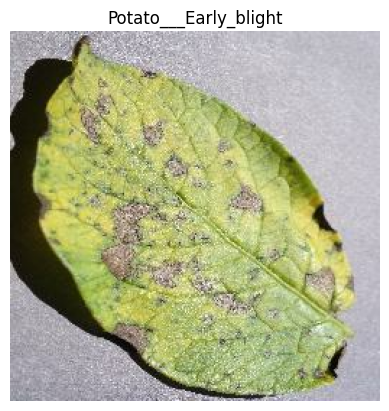

In [9]:
for image_batch,label_batch in dataset.take(1):
    plt.imshow(image_batch[0].numpy().astype("uint8"))
    plt.axis("off") #to remove axis
    plt.title(class_names[label_batch[0]])

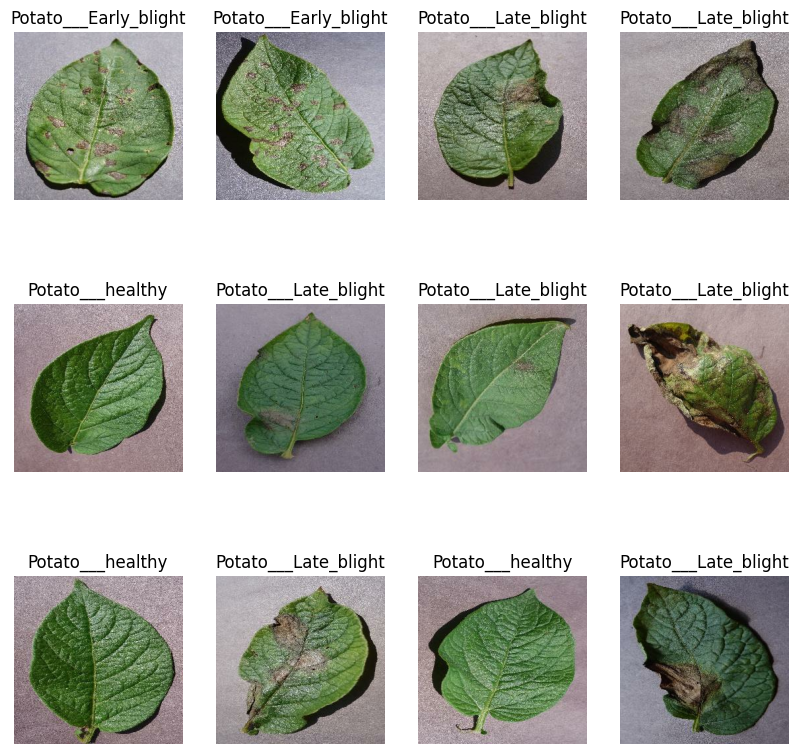

In [10]:
plt.figure(figsize=(10,10))
for image_batch,label_batch in dataset.take(1):
    for i in range(12):
        plt.subplot(3,4,i+1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.axis("off")
        plt.title(class_names[label_batch[i]])
        

In [11]:
def get_partition_size(ds,train_split=0.8,test_split=0.1,val_split=0.1,shuffle=True,shuffle_size=1000):
    ds_size=len(ds)
    train_size=int(0.8*ds_size)
    val_size=int(0.1*ds_size)
    train_ds=ds.take(train_size)
    val_ds=ds.skip(train_size).take(val_size)
    test_ds=ds.skip(train_size).skip(val_size)
    return train_ds,val_ds,test_ds


In [12]:
train_ds,val_ds,test_ds=get_partition_size(dataset)

In [13]:
len(test_ds)

8

In [14]:
train_ds=train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds=val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds=test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [15]:
resize_and_rescale=tf.keras.Sequential([
    layers.Resizing(256, 256),
    layers.Rescaling(1./255)])

In [16]:
data_augmentation=tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2)])

In [17]:
input_shape = (256, 256, 3)

model = models.Sequential([
    layers.Input(shape=input_shape),

    resize_and_rescale,
    data_augmentation,

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(3, activation='softmax'),
])


In [19]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,747 (717.76 KB)

 Trainable params: 183,747 (717.76 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy'])

In [25]:
history=model.fit(
    train_ds,
    epochs=50,
    batch_size=32,
    verbose=1,
    validation_data=val_ds)

Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 38s 683ms/step - accuracy: 0.4983 - loss: 0.8893 - val_accuracy: 0.5312 - val_loss: 0.8912
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 36s 665ms/step - accuracy: 0.6615 - loss: 0.7515 - val_accuracy: 0.5312 - val_loss: 0.9415
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 35s 655ms/step - accuracy: 0.7569 - loss: 0.5318 - val_accuracy: 0.7917 - val_loss: 0.4634
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 38s 711ms/step - accuracy: 0.8472 - loss: 0.3914 - val_accuracy: 0.8802 - val_loss: 0.2620
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 36s 676ms/step - accuracy: 0.8727 - loss: 0.3062 - val_accuracy: 0.9115 - val_loss: 0.2112
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 42s 772ms/step - accuracy: 0.8704 - loss: 0.3312 - val_accuracy: 0.8958 - val_loss: 0.2899
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 37s 687ms/step - accuracy: 0.9167 - loss: 0.2186 - val_accuracy: 0.9583 - val_loss: 0.1540
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 38s 695ms/step - accuracy: 0.9242 - loss: 0.2035 - val_accu

In [26]:
scores=model.evaluate(test_ds)

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 156ms/step - accuracy: 0.9921 - loss: 0.0153


In [27]:
scores


[0.01525595411658287, 0.9920634627342224]

In [28]:
history

In [31]:
history.params

{'verbose': 1, 'epochs': 50, 'steps': 54}

In [32]:
history.history['accuracy']

[0.4982638955116272,
 0.6614583134651184,
 0.7569444179534912,
 0.8472222089767456,
 0.8726851940155029,
 0.8703703880310059,
 0.9166666865348816,
 0.9241898059844971,
 0.9247685074806213,
 0.9444444179534912,
 0.9369212985038757,
 0.9305555820465088,
 0.9525462985038757,
 0.9623842835426331,
 0.9612268805503845,
 0.9722222089767456,
 0.9693287014961243,
 0.9751157164573669,
 0.9756944179534912,
 0.9704861044883728,
 0.9809027910232544,
 0.9832175970077515,
 0.9884259104728699,
 0.9826388955116272,
 0.9606481194496155,
 0.9675925970077515,
 0.9861111044883728,
 0.9907407164573669,
 0.9901620149612427,
 0.9722222089767456,
 0.9884259104728699,
 0.9814814925193787,
 0.9918981194496155,
 0.9785879850387573,
 0.9895833134651184,
 0.9942129850387573,
 0.9953703880310059,
 0.9901620149612427,
 0.9913194179534912,
 0.9837962985038757,
 0.9942129850387573,
 0.9942129850387573,
 0.9924768805503845,
 0.9872685074806213,
 0.9837962985038757,
 0.9820601940155029,
 0.9924768805503845,
 0.9965277910

In [34]:

history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [35]:
acc=history.history['accuracy']
val_acc=history.history['val_accuracy']
loss=history.history['loss']
val_loss=history.history['val_loss']

Text(0.5, 1.0, 'training and validation loss')

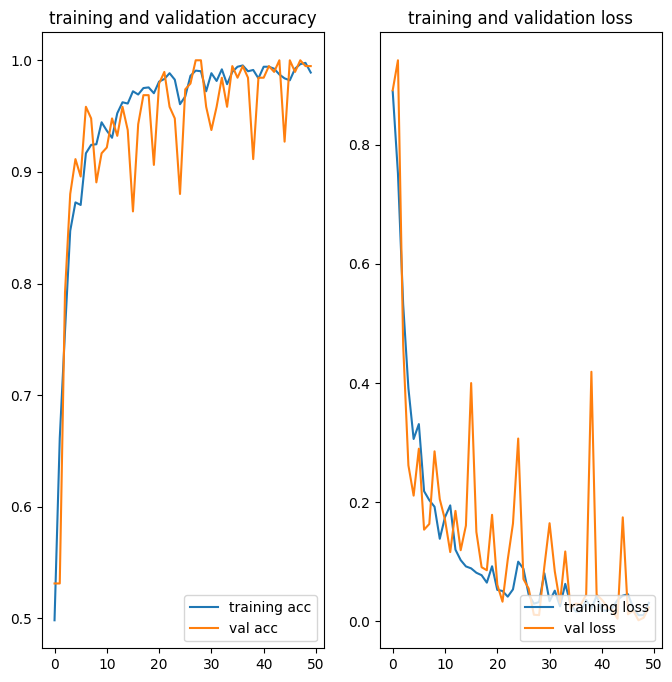

In [39]:
plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.plot(range(50),acc,label="training acc")
plt.plot(range(50),val_acc,label="val acc")
plt.legend(loc="lower right")
plt.title("training and validation accuracy")
plt.subplot(1,2,2)
plt.plot(range(50),loss,label="training loss")
plt.plot(range(50),val_loss,label="val loss")
plt.legend(loc="lower right")
plt.title("training and validation loss")





actual: Potato___Late_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
predicted: Potato___Late_blight


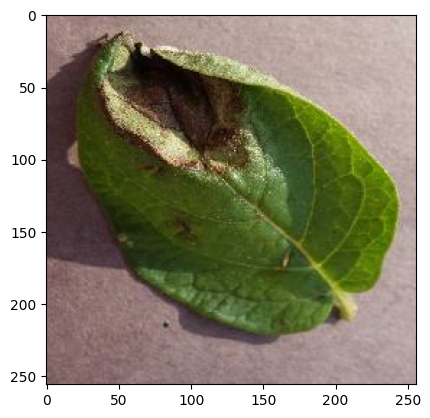

In [59]:
import numpy as np
for image_batch,label_batch in dataset.take(1):
    first_image=image_batch[0].numpy().astype("uint8")
    first_label=label_batch[0].numpy()
    plt.imshow(first_image)
    print("actual:",class_names[first_label])
    batch_preditction=model.predict(image_batch)
    print("predicted:",class_names[np.argmax(batch_preditction[0])])

In [60]:
def predict(model,img):
    img_array=tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array=tf.expand_dims(img_array,0)
    predictions=model.predict(img_array)
    predicted_class=class_names[np.argmax(predictions[0])]
    confidence=round(100*np.max(predictions[0]),2)
    return predicted_class,confidence
    

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


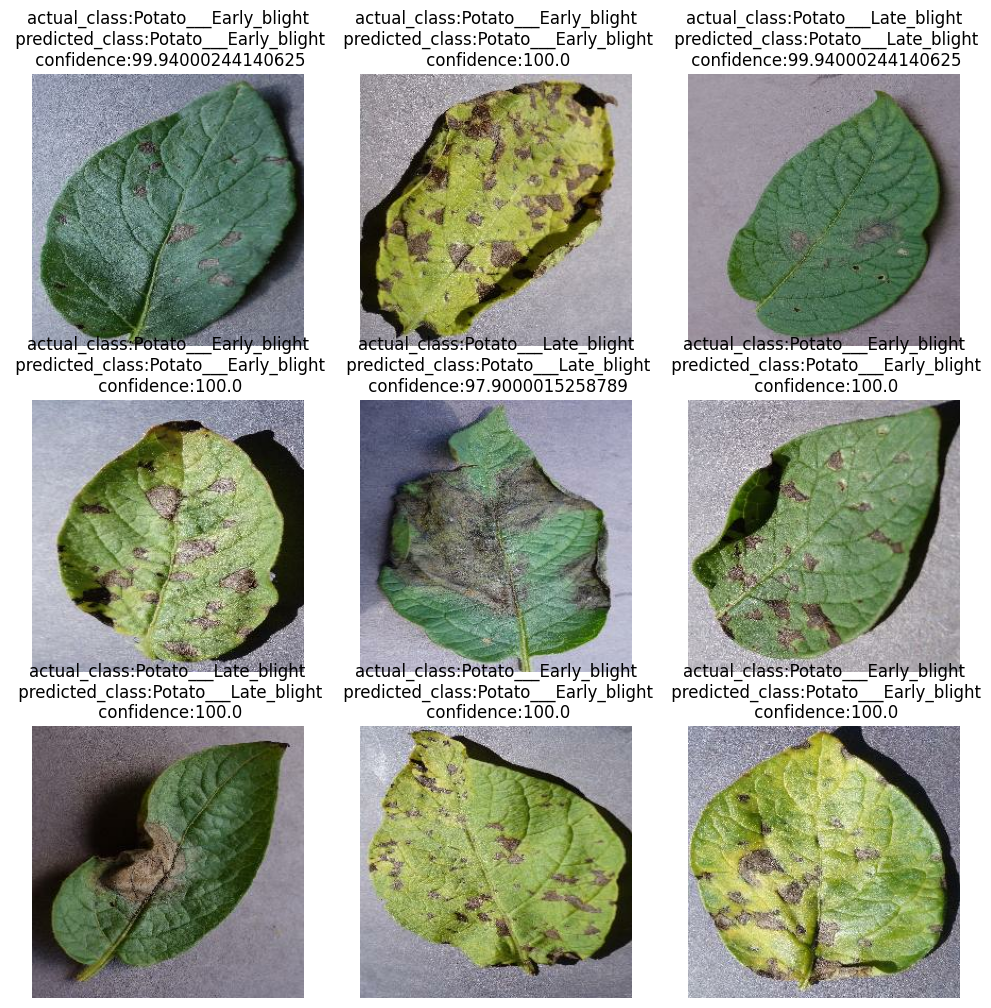

In [66]:
plt.figure(figsize=(12,12))
for images,labels in test_ds.take(1):
    for i in range(9):
        ax=plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        predicted_class,confidence=predict(model,images[i].numpy())
        actual_class=class_names[labels[i]]
        plt.title(f"actual_class:{actual_class}\n predicted_class:{predicted_class}\n confidence:{confidence}")
        plt.axis("off")

In [67]:
import os

In [68]:
os.listdir()

['.DS_Store',
 'Untitled.ipynb',
 'training.ipynb',
 '.virtual_documents',
 '.ipynb_checkpoints',
 'potato-disease']

In [71]:
model.export("models/1")

INFO:tensorflow:Assets written to: models/1/assets


INFO:tensorflow:Assets written to: models/1/assets


Saved artifact at 'models/1'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  5483511632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5483505872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5491237392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5491238160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5491238352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5491237584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5491240080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5491238544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5491240464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5491240272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5491237776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5491239

In [72]:
model.save("models/1.keras")